<a href="https://colab.research.google.com/github/Srideep-Kundu/MLProjects/blob/main/LinearRegressionFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###Loading and a brief analysis of our data

In [2]:
salary_df = pd.read_csv('/content/salary_data.csv')

In [5]:
salary_df.shape

(30, 2)

In [6]:
salary_df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


from matplotlib import pyplot as plt
_df_0['YearsExperience'].plot(kind='hist', bins=20, title='YearsExperience')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Salary'].plot(kind='hist', bins=20, title='Salary')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='YearsExperience', y='Salary', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['YearsExperience']
  ys = series['Salary']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('YearsExperience', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('YearsExperience')
_ = plt.ylabel('Salary')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['YearsExperience']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'YearsExperience'}, axis=1)
              .sort_values('YearsExperience', ascending=True))
  xs = counted['YearsExperience']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('YearsExperience', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('YearsExperience')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['YearsExperience'].plot(kind='line', figsize=(8, 4), title='YearsExperience')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['Salary'].plot(kind='line', figsize=(8, 4), title='Salary')
plt.gca().spines[['top', 'right']].set_visible(False)

In [9]:
X_train = salary_df.drop(columns = 'Salary', axis = 1)
Y_train = salary_df['Salary']

In [29]:
print(X_train)
print(Y_train)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [65]:
type(X_train)
X_train = X_train[:28]
Y_train = Y_train[:28]
X_train.shape

(28, 1)

In [66]:
X_train = np.asarray(X_train)
Y_train = np.asarray(Y_train)

In [67]:
type(X_train)
print(X_train.shape, Y_train.shape)
print(X_train)

(28, 1) (28,)
[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]
 [2.9]
 [3. ]
 [3.2]
 [3.2]
 [3.7]
 [3.9]
 [4. ]
 [4. ]
 [4.1]
 [4.5]
 [4.9]
 [5.1]
 [5.3]
 [5.9]
 [6. ]
 [6.8]
 [7.1]
 [7.9]
 [8.2]
 [8.7]
 [9. ]
 [9.5]
 [9.6]]


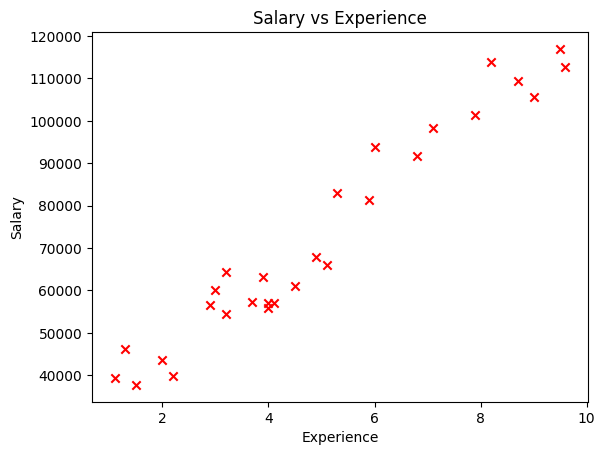

In [68]:
#Plotting our data
plt.scatter(X_train, Y_train, marker='x', c='r')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

###Writing the function to compute the cost

In [69]:
def compute_cost(X, Y, w, b):
  m = X.shape[0]
  cost = 0
  for i in range(m):
    f_wb = w * X[i] + b
    cost += (f_wb - Y[i]) ** 2
  total_cost = cost / (2 * m)
  return total_cost

In [70]:
#Computing cost with initial parameters of w and b
initial_w = 2
initial_b = 1

cost = compute_cost(X_train, Y_train, initial_w, initial_b)
print(f'Cost at initial w: {cost}')

Cost at initial w: [2.95009147e+09]


###Computing Gradient

In [71]:
def compute_gradient(X, Y, w, b):
  m = X.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb = w * X[i] + b
    dj_dw += (f_wb - Y[i]) * X[i]
    dj_db += (f_wb - Y[i])
  dj_dw /= m
  dj_db /= m

  return dj_dw, dj_db

In [72]:
#Computing gradient with w and b
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, Y_train, initial_w, initial_b)
print(f'dj_dw at initial w: {tmp_dj_dw}')
print(f'dj_db at initial b: {tmp_dj_db}')

dj_dw at initial w: [-420774.20357143]
dj_db at initial b: [-72708.10714286]


###Computing Gradient Descent

In [73]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  m = len(x)

  j_history = []
  w_history = []
  w = w_in
  b = b_in

  for i in range(num_iters):
    dj_dw, dj_db = compute_gradient(x, y, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Save cost J at each iteration
    if i < 100000: # prevents resource exhaustion
      cost = compute_cost(x, y, w, b)
      j_history.append(cost)

    if i % 100 == 0:
      w_history.append(w)
      print(f"Iteration {i:4}: Cost {float(j_history[-1]):8.2f}   ")
  return w, b, j_history, w_history

In [74]:
# Running the gradient descent algorithm
initial_w = 0
initial_b = 0
iterations = 1500
alpha = 0.01

w,b, j_history, w_history = gradient_descent(X_train, Y_train, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print("w,b found by gradient descent:", w, b)

/tmp/ipython-input-2074096304.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Iteration {i:4}: Cost {float(j_history[-1]):8.2f}   ")


Iteration    0: Cost 1416254747.29   
Iteration  100: Cost 53422625.15   
Iteration  200: Cost 41199807.77   
Iteration  300: Cost 33024371.38   
Iteration  400: Cost 27556093.65   
Iteration  500: Cost 23898544.39   
Iteration  600: Cost 21452131.22   
Iteration  700: Cost 19815806.75   
Iteration  800: Cost 18721323.69   
Iteration  900: Cost 17989260.33   
Iteration 1000: Cost 17499607.48   
Iteration 1100: Cost 17172094.96   
Iteration 1200: Cost 16953032.72   
Iteration 1300: Cost 16806509.27   
Iteration 1400: Cost 16708504.60   
w,b found by gradient descent: [9753.42813926] [24200.48030251]


In [75]:
m = X_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
  predicted[i] = w * X_train[i] + b

/tmp/ipython-input-3492303874.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted[i] = w * X_train[i] + b


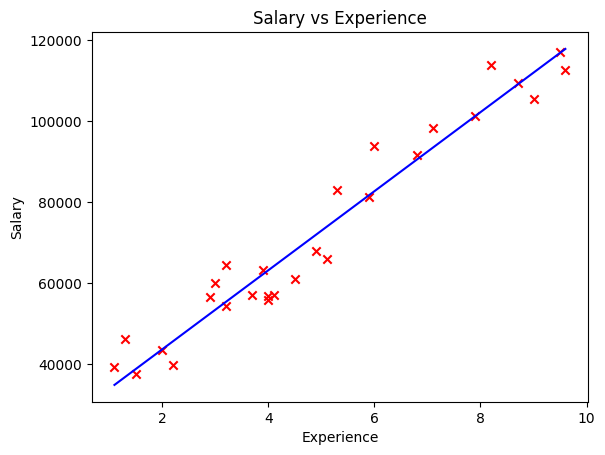

In [76]:
# Plotting the linear graph
plt.plot(X_train, predicted, c = "b")
# Plotting the scatter plot
plt.scatter(X_train, Y_train, marker= 'x', c='r')
plt.title("Salary vs Experience")
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

###Predicting certain values using our model

In [77]:
#We have two test examples with us
predict1 = 10.3 * w + b # Original salary $122391
print(f"Predicted salary for 10.3 years of experience will be ${predict1}")

Salary for 10.3 years of experience will be $[124660.79013685]


In [78]:
predict2 = 10.5 * w + b # Original salary $121872
print(f"Predicted salary for 10.5 years of experience will be ${predict2}")

Predicted salary for 10.5 years of experience will be $[126611.4757647]
